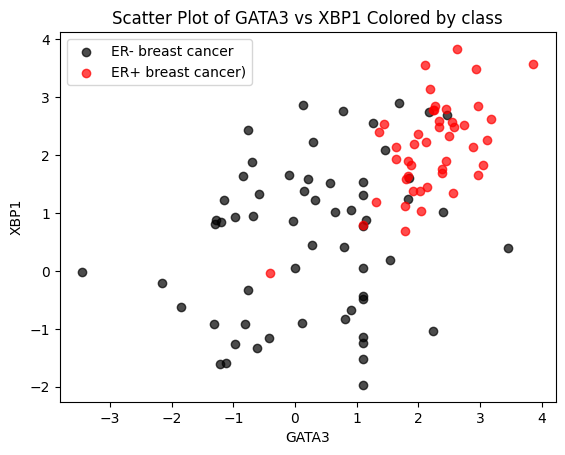

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

DataFrame = pd.read_csv("filtered.tsv.gz", sep="\t")
Data1 = pd.read_csv("class.tsv", sep="\t", header=None)
Data2 = pd.read_csv("columns.tsv.gz", sep="\t", comment="#")    

x = (Data2.loc[Data2['GeneSymbol'] == 'GATA3', 'ID'].values[0])
y = Data2.loc[Data2['GeneSymbol'] == 'XBP1', 'ID'].values[0]

x = " " + str(x)
y = " " + str(y)

X = DataFrame[x].values
Y = DataFrame[y].values
Z = Data1[0].values

m0 = (Z == 0)
m1 = (Z == 1)

# Plot
plt.scatter(X[m0], Y[m0], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(X[m1], Y[m1], color='red', alpha=0.7, label='ER+ breast cancer)')

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Scatter Plot of GATA3 vs XBP1 Colored by class")
plt.legend()
plt.show()

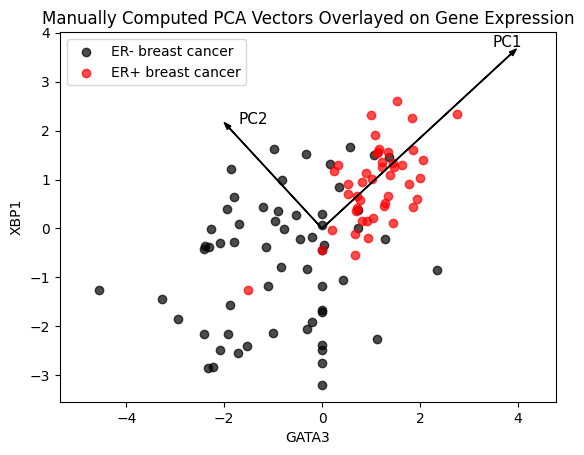

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

x_v = X
y_v = Y
z_v = Z

data = np.vstack((x_v, y_v)).T
mean = np.mean(data, axis=0)
centred_data = (data - mean)

mat = np.cov(centred_data.T)

eig_vals, eig_vecs = np.linalg.eig(mat)

sorted = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted]
eig_vecs = eig_vecs[:, sorted]

components = eig_vecs.T 
explained = eig_vals     

mask0 = (z_v == 0)
mask1 = (z_v == 1)

plt.scatter(centred_data[mask0, 0], centred_data[mask0, 1], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(centred_data[mask1, 0], centred_data[mask1, 1], color='red', alpha=0.7, label='ER+ breast cancer')

for i in range(2):
    start = np.array([0, 0])
    end = np.sqrt(explained[i]) * components[i] * 3
    
    plt.arrow(start[0], start[1],
              end[0], end[1],
              color='black', width=0.01, head_width=0.1)
    
    plt.text(end[0]*0.9, end[1]*1.04, f'PC{i+1}', color='black', fontsize=11)

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Manually Computed PCA Vectors Overlayed on Gene Expression")
plt.legend()
plt.axis('equal')
plt.show()


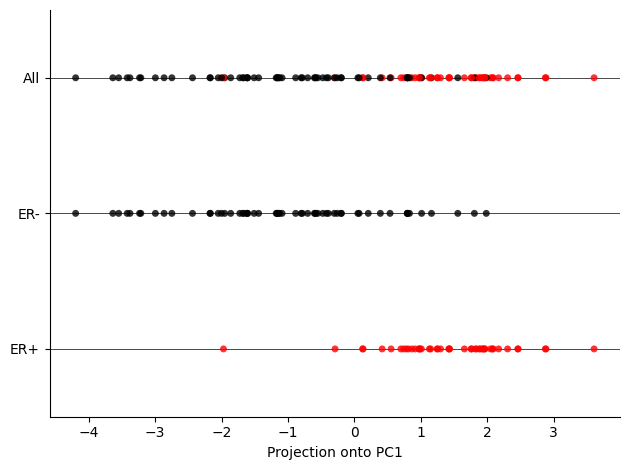

In [4]:
pc1 = eig_vecs[:, 0]

pc1_project = centred_data @ pc1

df_all = pd.DataFrame({
    "PC1": pc1_project,
    "Group": "All",
    "Color": np.where(Z == 0, "black", "red")
})

df_plus = pd.DataFrame({
    "PC1": pc1_project[Z == 1],
    "Group": "ER+",
    "Color": "red"
})

df_minus = pd.DataFrame({
    "PC1": pc1_project[Z == 0],
    "Group": "ER-",
    "Color": "black"
})

plot = pd.concat([df_all, df_minus, df_plus], ignore_index=True)

ax = sns.stripplot(data=plot, x="PC1", y="Group", hue="Color", 
                   palette={"black": "black", "red": "red"}, 
                   dodge=False, jitter=False, alpha=0.8, size=5)

ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0) 

plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)  # Remove legend
sns.despine()
plt.tight_layout()
plt.show()
